# **DUSt3R :3D Reconstruction From 2D Images :**

In [1]:
# uv pip install torch==2.7.0+cu118 torchvision==0.22.0+cu118 --index-url https://download.pytorch.org/whl/cu118

3D Reconstruction/
│
├── data/
│   └── input/
│       └── video.mp4
│
├── results/
│   └── dust3r/
│       │
│       ├── exp_01_baseline/
│       │   ├── dataset/
│       │   │   ├── frames/
│       │   │   └── dataset_info.json
│       │   │
│       │   ├── results/
│       │   │   ├── point_cloud.ply
│       │   │   ├── confidence.ply
│       │   │   └── metadata.json
│       │   │
│       │   └── logs/
│       │
│       ├── exp_02_oneref/
│       │   ├── dataset/
│       │   │   ├── frames/
│       │   │   └── dataset_info.json
│       │   │
│       │   ├── results/
│       │   │   ├── point_cloud.ply
│       │   │   └── metadata.json
│       │   │
│       │   └── logs/
│       │
│       ├── exp_03_more_frames/
│       │   ├── dataset/
│       │   ├── results/
│       │   └── logs/
│       │
│       └── ...
│
├── src/
│   └── dust3r/
│       ├── frame_extractor.py
│       ├── reconstruction.py
│       ├── visualization.py
│       └── pipeline.py
│
└── notebook/
    └── dust3r/
        ├── 01_data_processing.ipynb
        ├── 02_two_image_test.ipynb
        ├── 03_global_alignment.ipynb
        └── 04_experiments.ipynb

## **Dust3R dataset Preprocessing :**

In [2]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd()

while PROJECT_ROOT.name != "3D Reconstruction":
    PROJECT_ROOT = PROJECT_ROOT.parent

# Our project code
sys.path.insert(0, str(PROJECT_ROOT))

# Official DUSt3R repository
sys.path.insert(0, str(PROJECT_ROOT / "dust3r"))

print("Project root:", PROJECT_ROOT)
print("Official DUSt3R:", PROJECT_ROOT / "dust3r")

Project root: d:\3D Reconstruction
Official DUSt3R: d:\3D Reconstruction\dust3r


In [6]:
from src.dust3r.data_preprocessing import extract_uniform_frames

In [7]:
Path.cwd().parent

WindowsPath('d:/3D Reconstruction/notebook')

In [8]:


video_path = PROJECT_ROOT / "video"/ "video.mp4"

video_path

WindowsPath('d:/3D Reconstruction/video/video.mp4')

In [9]:


output_dir = (
        PROJECT_ROOT
        /"src"
        / "results"
        / "dust3r"
        / "exp_01_baseline"
        / "dataset"
        / "frames"
    )

extract_uniform_frames(
        video_path=video_path,
        output_dir=output_dir,
        num_frames=20,
    )

Video: d:\3D Reconstruction\video\video.mp4
Original frames: 397
Original FPS: 30.00
Selected frames: 20
Saved to: d:\3D Reconstruction\src\results\dust3r\exp_01_baseline\dataset\frames
Metadata: d:\3D Reconstruction\src\results\dust3r\exp_01_baseline\dataset\dataset_info.json


In [10]:

frames=sorted(output_dir.glob("*.jpg"))

print(f'Number of Frames : {len(frames)}')

for frame in frames:
    print(frame.name)

Number of Frames : 20
frame_0000.jpg
frame_0001.jpg
frame_0002.jpg
frame_0003.jpg
frame_0004.jpg
frame_0005.jpg
frame_0006.jpg
frame_0007.jpg
frame_0008.jpg
frame_0009.jpg
frame_0010.jpg
frame_0011.jpg
frame_0012.jpg
frame_0013.jpg
frame_0014.jpg
frame_0015.jpg
frame_0016.jpg
frame_0017.jpg
frame_0018.jpg
frame_0019.jpg


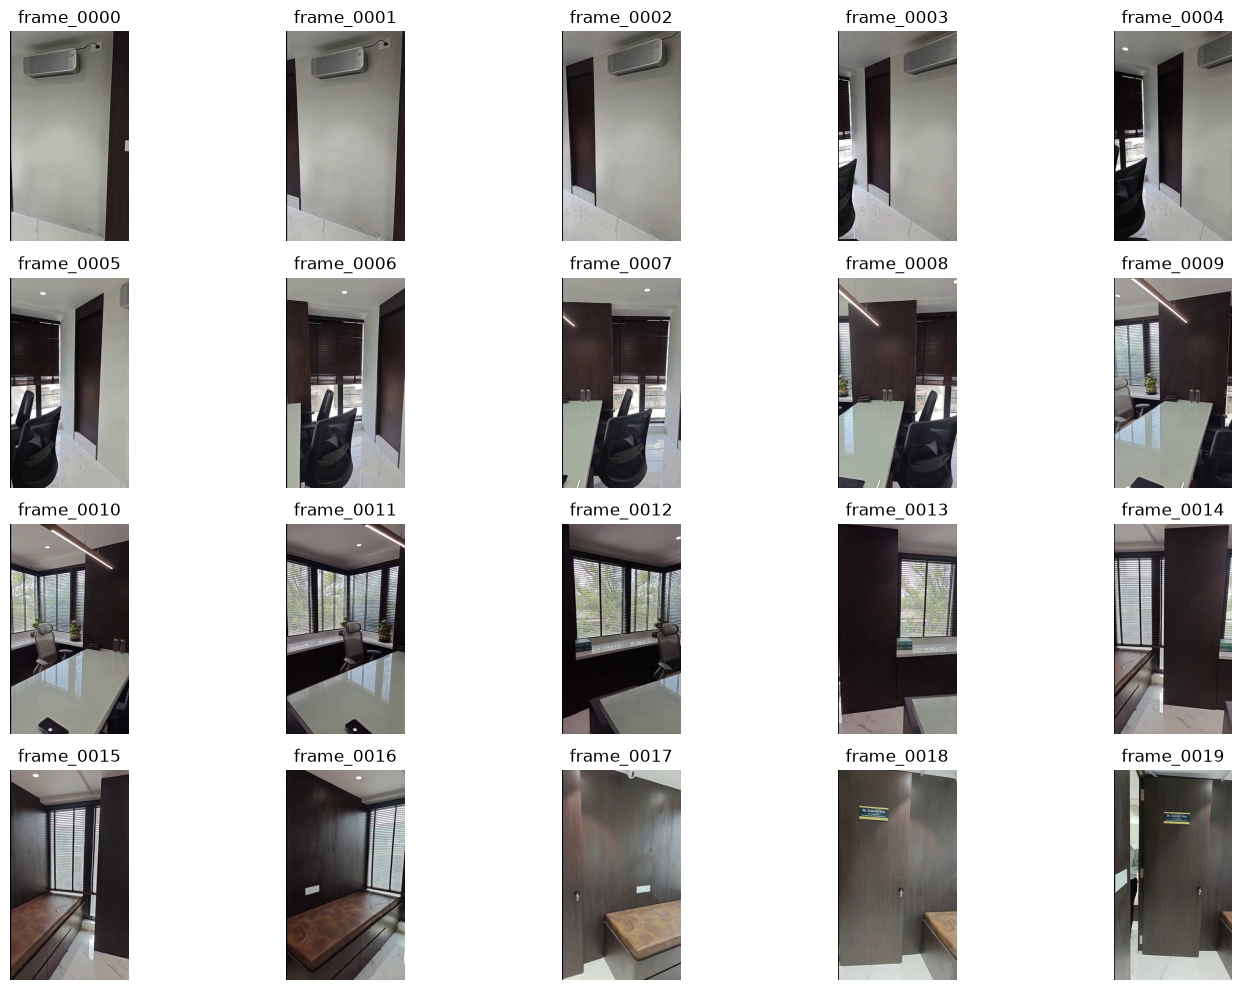

In [11]:
import matplotlib.pyplot as plt
from PIL import Image


fig,axes=plt.subplots(4,5,figsize=(15,10))

for ax ,frame_path in zip(axes.flat,frames):
    image=Image.open(frame_path)

    ax.imshow(image)
    ax.set_title(frame_path.stem)
    ax.axis("off")

plt.tight_layout()
plt.show()

In [12]:
from PIL import Image

for frame_path in frames[:3]:
    image = Image.open(frame_path)

    print(
        frame_path.name,
        "size =", image.size,
        "mode =", image.mode
    )

frame_0000.jpg size = (408, 720) mode = RGB
frame_0001.jpg size = (408, 720) mode = RGB
frame_0002.jpg size = (408, 720) mode = RGB


## **Working with Dust3R Model :**

In [13]:
# !git clone --recursive https://github.com/naver/dust3r

In [14]:
# # * downloading the Model :

from src.dust3r.model_manager import get_checkpoint

CHECKPOINT_DIR = (
    PROJECT_ROOT
    / "dust3r"
    / "checkpoints"
)

CHECKPOINT_DIR


WindowsPath('d:/3D Reconstruction/dust3r/checkpoints')

In [15]:
checkpoint_path = get_checkpoint(
    model_name="512_dpt",
    checkpoint_dir=CHECKPOINT_DIR,
)

print(checkpoint_path)

Checkpoint already exists:
d:\3D Reconstruction\dust3r\checkpoints\DUSt3R_ViTLarge_BaseDecoder_512_dpt.pth
d:\3D Reconstruction\dust3r\checkpoints\DUSt3R_ViTLarge_BaseDecoder_512_dpt.pth


In [16]:
checkpoint_path = get_checkpoint(
    model_name="512_linear",
    checkpoint_dir=CHECKPOINT_DIR,
)

print(checkpoint_path)

Checkpoint already exists:
d:\3D Reconstruction\dust3r\checkpoints\DUSt3R_ViTLarge_BaseDecoder_512_linear.pth
d:\3D Reconstruction\dust3r\checkpoints\DUSt3R_ViTLarge_BaseDecoder_512_linear.pth


In [17]:
checkpoint_path = get_checkpoint(
    model_name="224_linear",
    checkpoint_dir=CHECKPOINT_DIR,
)

print(checkpoint_path)

Checkpoint already exists:
d:\3D Reconstruction\dust3r\checkpoints\DUSt3R_ViTLarge_BaseDecoder_224_linear.pth
d:\3D Reconstruction\dust3r\checkpoints\DUSt3R_ViTLarge_BaseDecoder_224_linear.pth


## **Loading the Model + Inference Test :**

In [18]:
import dust3r

print(dust3r.__file__)

d:\3D Reconstruction\dust3r\dust3r\__init__.py


In [3]:
from pathlib import Path

from src.dust3r.reconstruction import reconstruct



frames_dir = (
    PROJECT_ROOT
    /"src"
    / "results"
    / "dust3r"
    / "exp_01_baseline"
    / "dataset"
    / "frames"
)

checkpoint_path = (
    PROJECT_ROOT
    / "dust3r"
    / "checkpoints"
    / "DUSt3R_ViTLarge_BaseDecoder_512_dpt.pth"
)

output_dir = (
    PROJECT_ROOT
    /"src"
    / "results"
    / "dust3r"
    / "exp_01_baseline"
    / "results"
)



d:\3D Reconstruction\dust3r\dust3r\cloud_opt\base_opt.py:275: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  @torch.cuda.amp.autocast(enabled=False)


In [24]:
print(frames_dir)
print(frames_dir.exists())
print(list(frames_dir.glob("*"))[:10])

d:\3D Reconstruction\src\results\dust3r\exp_01_baseline\dataset\frames
True
[WindowsPath('d:/3D Reconstruction/src/results/dust3r/exp_01_baseline/dataset/frames/frame_0000.jpg'), WindowsPath('d:/3D Reconstruction/src/results/dust3r/exp_01_baseline/dataset/frames/frame_0001.jpg'), WindowsPath('d:/3D Reconstruction/src/results/dust3r/exp_01_baseline/dataset/frames/frame_0002.jpg'), WindowsPath('d:/3D Reconstruction/src/results/dust3r/exp_01_baseline/dataset/frames/frame_0003.jpg'), WindowsPath('d:/3D Reconstruction/src/results/dust3r/exp_01_baseline/dataset/frames/frame_0004.jpg'), WindowsPath('d:/3D Reconstruction/src/results/dust3r/exp_01_baseline/dataset/frames/frame_0005.jpg'), WindowsPath('d:/3D Reconstruction/src/results/dust3r/exp_01_baseline/dataset/frames/frame_0006.jpg'), WindowsPath('d:/3D Reconstruction/src/results/dust3r/exp_01_baseline/dataset/frames/frame_0007.jpg'), WindowsPath('d:/3D Reconstruction/src/results/dust3r/exp_01_baseline/dataset/frames/frame_0008.jpg'), Windo

In [25]:
reconstruct(
    frames_dir=frames_dir,
    checkpoint_path=checkpoint_path,
    output_dir=output_dir,
)

Device: cuda
Frames: d:\3D Reconstruction\src\results\dust3r\exp_01_baseline\dataset\frames
Checkpoint: d:\3D Reconstruction\dust3r\checkpoints\DUSt3R_ViTLarge_BaseDecoder_512_dpt.pth

Loading DUSt3R model...
... loading model from d:\3D Reconstruction\dust3r\checkpoints\DUSt3R_ViTLarge_BaseDecoder_512_dpt.pth
instantiating : AsymmetricCroCo3DStereo(enc_depth=24, dec_depth=12, enc_embed_dim=1024, dec_embed_dim=768, enc_num_heads=16, dec_num_heads=12, pos_embed='RoPE100', patch_embed_cls='PatchEmbedDust3R', img_size=(512, 512), head_type='dpt', output_mode='pts3d', depth_mode=('exp', -inf, inf), conf_mode=('exp', 1, inf), landscape_only=False)
<All keys matched successfully>
Model loaded.

Loading 20 images...
>> Loading a list of 20 images
 - adding d:\3D Reconstruction\src\results\dust3r\exp_01_baseline\dataset\frames\frame_0000.jpg with resolution 408x720 --> 288x512
 - adding d:\3D Reconstruction\src\results\dust3r\exp_01_baseline\dataset\frames\frame_0001.jpg with resolution 408x72

  0%|          | 0/80 [00:00<?, ?it/s]d:\3D Reconstruction\dust3r\dust3r\inference.py:44: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=bool(use_amp)):
d:\3D Reconstruction\dust3r\dust3r\model.py:264: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=False):
d:\3D Reconstruction\dust3r\dust3r\inference.py:48: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=False):
100%|██████████| 80/80 [00:22<00:00,  3.52it/s]


Inference completed.

Running global alignment...
 init edge (16*,17*) score=np.float64(210.29232788085938)
 init edge (17,18*) score=np.float64(120.10826873779297)
 init edge (15*,16) score=np.float64(93.87268829345703)
 init edge (17,19*) score=np.float64(80.87688446044922)
 init edge (15,14*) score=np.float64(66.02478790283203)
 init edge (14,13*) score=np.float64(57.175804138183594)
 init edge (14,12*) score=np.float64(31.2253360748291)
 init edge (13,11*) score=np.float64(29.074186325073242)
 init edge (11,10*) score=np.float64(48.204246520996094)
 init edge (10,8*) score=np.float64(41.80497741699219)
 init edge (10,9*) score=np.float64(57.448760986328125)
 init edge (7*,9) score=np.float64(47.25296401977539)
 init edge (5*,7) score=np.float64(57.40005111694336)
 init edge (6*,5) score=np.float64(57.16281509399414)
 init edge (3*,5) score=np.float64(111.40771484375)
 init edge (3,1*) score=np.float64(130.18479919433594)
 init edge (4*,3) score=np.float64(129.8851318359375)
 init e

100%|██████████| 300/300 [08:19<00:00,  1.67s/it, lr=1.27413e-06 loss=0.00643887]


Global alignment completed.
Final loss: 0.006438867188990116

Extracting point cloud...
Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.
Point count: 2781591

Point cloud saved:
d:\3D Reconstruction\src\results\dust3r\exp_01_baseline\results\point_cloud.ply


WindowsPath('d:/3D Reconstruction/src/results/dust3r/exp_01_baseline/results/point_cloud.ply')

In [4]:
output_dir

WindowsPath('d:/3D Reconstruction/src/results/dust3r/exp_01_baseline/results')

In [5]:
point_cloud=output_dir/"point_cloud.ply"
point_cloud

WindowsPath('d:/3D Reconstruction/src/results/dust3r/exp_01_baseline/results/point_cloud.ply')

In [6]:
import open3d as o3d

point_cloud=output_dir/"point_cloud.ply"


dense_pcd = o3d.io.read_point_cloud(
    point_cloud
)


print(dense_pcd)
print("Dense points:", len(dense_pcd.points))

Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.
PointCloud with 2781591 points.
Dense points: 2781591


In [8]:
o3d.visualization.draw_geometries([dense_pcd])
